*   For a long time, how to calculate
the area of a circle remained a mystery.
> *   Then, in Ancient Greece, the mathematician Archimedes came up with the clever idea to inscribe a series of polygons with increasing numbers of vertices on the inside of a circle (:numref:`fig_circle_area`).
> *   For a polygon with $n$ vertices, we obtain $n$ triangles.
> *   The height of each triangle approaches the radius $r$ as we partition the circle more finely.
> *   At the same time, its base approaches $2 \pi r/n$, since the ratio between arc and secant approaches 1 for a large number of vertices.
> *   Thus, the area of the polygon approaches $n \cdot r \cdot \frac{1}{2} (2 \pi r/n) = \pi r^2$.

    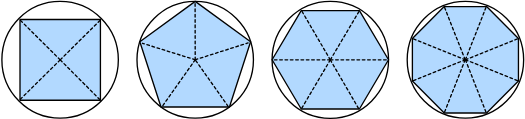

*   This limiting procedure is at the root of both *differential calculus* and *integral calculus*.
> *   The former can tell us how to increase or decrease a function's value by manipulating its arguments.
> *   This comes in handy for the *optimization problems* that we face in deep learning, where we repeatedly update our parameters in order to decrease the loss function.
> *   Optimization addresses how to fit our models to training data, and calculus is its key prerequisite.
> *   However, do not forget that our ultimate goal is to perform well on *previously unseen* data.
> *   That problem is called *generalization* and will be a key focus of other chapters.

In [13]:
!pip install d2l --no-deps #current d2l version may not be compatible to colab's NumPy
!pip install numpy==1.26.4 jupyter matplotlib

%matplotlib inline
import numpy as np
from matplotlib_inline import backend_inline
import matplotlib.pyplot as plt
from d2l import torch as d2l

# 2.4.1. Derivatives and Differentiation

*   Put simply, a *derivative* is the rate of change
in a function with respect to changes in its arguments.
*   Derivatives can tell us how rapidly a loss function
would increase or decrease were we
to *increase* or *decrease* each parameter
by an infinitesimally small amount.
*   Formally, for functions $f: \mathbb{R} \rightarrow \mathbb{R}$,
that map from scalars to scalars,
[**the *derivative* of $f$ at a point $x$ is defined as**]

**$$f'(x) = \lim_{h \rightarrow 0} \frac{f(x+h) - f(x)}{h}.$$**

> *   This term on the right hand side is called a *limit* and it tells us what happens to the value of an expression as a specified variable approaches a particular value.
> *   This limit tells us what the ratio between a perturbation $h$ and the change in the function value $f(x + h) - f(x)$ converges to as we shrink its size to zero.
> *   When $f'(x)$ exists, $f$ is said to be *differentiable* at $x$; and when $f'(x)$ exists for all $x$ on a set, e.g., the interval $[a,b]$, we say that $f$ is differentiable on this set.
> *   Not all functions are differentiable, including many that we wish to optimize, such as accuracy and the area under the receiving operating characteristic (AUC).
> *   However, because computing the derivative of the loss is a crucial step in nearly all algorithms for training deep neural networks, we often optimize a differentiable *surrogate* instead.
*   In ML, derivatives say [**“If I slightly change this weight, does the error go up or down?”**]


*   We can interpret the derivative $f'(x)$ as the *instantaneous* rate of change of $f(x)$ with respect to $x$.
*   Let's develop some intuition with an example. (**Define $u = f(x) = 3x^2-4x$.**)

In [3]:
def f(x):
  return 3 * x ** 2 - 4 * x

* [**Setting $x=1$, we see that $\frac{f(x+h) - f(x)}{h}$**] (**approaches $2$
as $h$ approaches $0$.**)
* While this experiment lacks the rigor of a mathematical proof, we can quickly see that indeed $f'(1) = 2$.


In [4]:
for h in 10.0**np.arange(-1, -6, -1):
  print(f'h={h:.5f}, numerical limit={(f(1+h)-f(1))/h:.5f}')

h=0.10000, numerical limit=2.30000
h=0.01000, numerical limit=2.03000
h=0.00100, numerical limit=2.00300
h=0.00010, numerical limit=2.00030
h=0.00001, numerical limit=2.00003


## A derivative is just a rule for tracking how a function changes when x changes.

---

# 1. All these symbols mean the same thing

If \( y = f(x) \), then all of these mean:

$$f'(x) = y' = \frac{dy}{dx} = \frac{df}{dx} = \frac{d}{dx} f(x) = Df(x) = D_x f(x),$$

Which simply says:

> **“How fast is the function changing at x?”**

### Why so many versions?
Because different fields like different shorthand:
- $f'(x)$: algebra / pure math
- $\frac{dy}{dx}$: physics / intuition (“change in y over change in x”)
- $\frac{d}{dx}$: operator form (“apply derivative to something”)
- $D f(x)$: machine-style / operator thinking

Same idea, different costumes.

---

# 2. Derivatives of basic functions (the core building blocks)

---

Constant: If nothing changes, slope is zero.

$\frac{d}{dx} C = 0$

---
Power rule: bring exponent down and reduce exponent by 1

$$
\frac{d}{dx} x^n = n x^{n-1}
$$

---

Exponential: function grows in a “self-reinforcing” way where slope = value
$$
\frac{d}{dx} e^x = e^x
$$

---

Logarithm: As x grows, changes become less and less sensitive.
$$
\frac{d}{dx} \ln x = \frac{1}{x}
$$


---

# 3. The 4 combination rules (how functions interact)

---

1. Constant multiple rule: constants just scale everything. If you multiply a function, you multiply its slope too.

$$
\frac{d}{dx}[C f(x)] = C f'(x)
$$

---

2. Sum rule: slopes add independently. No interaction between terms.
$$
\frac{d}{dx}[f(x) + g(x)] = f'(x) + g'(x)
$$

---

3. Product rule: when two things multiply, both can change, so both effects matter. One part changes while the other is fixed, then swap roles (2 contributions).

$$
\frac{d}{dx}[f(x)g(x)] = f(x)g'(x) + g(x)f'(x)
$$

---

4. Quotient rule: a ratio changes because both numerator and denominator change. Numerator helps (+). Denominator hurts (−)

$$
\frac{d}{dx}\frac{f(x)}{g(x)} = \frac{g(x)f'(x) - f(x)g'(x)}{g^2(x)}
$$

---

# 4. Example

We compute:

$$
\frac{d}{dx}[3x^2 - 4x]
$$

1: split using sum rule
$$
= \frac{d}{dx}(3x^2) - \frac{d}{dx}(4x)
$$

2: pull out constants
$$
= 3\frac{d}{dx}(x^2) - 4\frac{d}{dx}(x)
$$

3: apply power rule
$$
\frac{d}{dx}x^2 = 2x, \quad \frac{d}{dx}x = 1
$$

So:

$$
= 3(2x) - 4(1)
$$

4: simplify
$$
= 6x - 4
$$

---

# 5. What does this answer *mean*?

If we plug in x = 1,

$$
f'(1) = 6(1) - 4 = 2
$$

At \(x = 1\), the function is increasing at a rate of 2 per unit x.

# 2.4.2. Visualization Utilities

*   [**We can visualize the slopes of functions using the `matplotlib` library**].
*   We need to define a few functions.
> *   As its name indicates, `use_svg_display` tells `matplotlib` to output graphics in SVG format for crisper images.
> *   The comment `#@save` is a special modifier that allows us to save any function, class, or other code block to the `d2l` package so that we can invoke it later without repeating the code, e.g., via `d2l.use_svg_display()`.






In [5]:
def use_svg_display(): #@save
  """Use the svg format to display a plot in Jupyter."""
  backend_inline.set_matplotlib_formats('svg')

*   Conveniently, we can set figure sizes with `set_figsize`.
*   Since the import statement `from matplotlib import pyplot as plt`
was marked via `#@save` in the `d2l` package, we can call `d2l.plt`.


In [6]:
def set_figsize(figsize=(3.5, 2.5)): #@save
  """Set the figure size for matplotlib."""
  use_svg_display()
  d2l.plt.rcParams['figure.figsize'] = figsize # set runtime params of figsize as (3.5, 2.5)


*   The `set_axes` function can associate axes
with properties, including labels, ranges,
and scales.
> * The `axes` argument is usually `ax`, which is an instance of Matplotlib's `Axes` class.

In [7]:
#@save
def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
  """Set the axes for matplotlib."""
  axes.set_xlabel(xlabel), axes.set_ylabel(ylabel)
  axes.set_xscale(xscale), axes.set_yscale(yscale)
  axes.set_xlim(xlim), axes.set_ylim(ylim)
  if legend: #if a legend argument is given, map it to the given argument
    axes.legend(legend)
  axes.grid() #turns on the grid lines for the plot

*   With these three functions, we can define a `plot` function
to overlay multiple curves.
*   Much of the code here is just ensuring
that the sizes and shapes of inputs match.






In [8]:
#@save
def plot(X, Y=None, xlabel=None, ylabel=None, legend=[], xlim=None,
         ylim=None, xscale='linear', yscale='linear',
         fmts=('-', 'm--', 'g-.', 'r:'), figsize=(3.5, 2.5), axes=None):
  """Plot data points."""

  def has_one_axis(X): # True if X (tensor or list) has 1 axis
    return (hasattr(X, "ndim") and X.ndim == 1 or isinstance(X, list)
            and not hasattr(X[0], "__len__"))

  '''X has one axis if
    1) it has an 'ndim' attribute (e.g. a tensor or NumPy array) and ndim == 1
    2) it is a Python list whose 1st element does not have a length (e.g. it only contains scalar values instead of nested lists)
  '''

  if has_one_axis(X): X = [X]

  '''
    make x a list of datasets (e.g. from [1,2,3] to [[1,2,3]]) for plot loop iteration
    without a dataset, the zip function will only iterate each element, e.g. each of 1, 2 and 3, instead of the assembly [1,2,3]
  '''

  if Y is None:
    X, Y = [[]] * len(X), X
  #if user did not provide Y, make Y = X, and replace X with len(x) amounts of empty placeholders
  #matplotlib will use default X values to replace the X placeholders (matplotplib must have X values)

  elif has_one_axis(Y):
    Y = [Y]
  #if the user has provided Y and it is 1D, pack it as a dataset (e.g. [1,2,3] becomes [[1,2,3]]) for loop iteration

  if len(X) != len(Y):
    X = X * len(Y)
  #if the number of x-datasets differs from the number of y-datasets, repeat the entire X list so it has the same number of datasets as Y

  set_figsize(figsize)
  #call set_figsize() for the given figsize=(3.5, 2.5)

  if axes is None:
    axes = d2l.plt.gca()
  #if user did not provide the axes argument, use existing axes (from current figure)
  #or Matplotlib will create axes if there are no existing axes

  axes.cla()
  #clear any pre-existing axis (so that if the user passes the same axes repeatedly nothing accumulates)

  for x, y, fmt in zip(X, Y, fmts):
    axes.plot(x,y,fmt) if len(x) else axes.plot(y, fmt)
  #iterate over paired x-series, y-series, and line-format strings
  #1) if x is not empty or len(x) !=0, plot y against x
  #2) if x is empty (like x = [[], [], []] from the len(x) != len(y) config), plot y against Matplotlib's automatic x series

  set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
  #save all of the arguments and process created so its ready for plotting

*   Now we can [**plot the function $u = f(x)$ and its tangent line $y = 2x - 3$ at $x=1$**], where the coefficient $2$ is the slope of the tangent line.

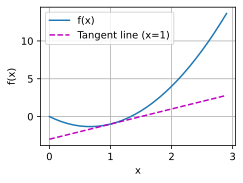

In [9]:
x = np.arange(0, 3, 0.1)
plot(x, [f(x), 2* x - 3], 'x', 'f(x)', legend=['f(x)', 'Tangent line (x=1)'])

# 2.4.3. Partial Derivatives and Gradients

* Thus far, we have been differentiating functions of just one variable.
* In deep learning, we also need to work with functions of *many* variables.
* We briefly introduce notions of the derivative that apply to such *multivariate* functions.
>
> * Let $y = f(x_1, x_2, \ldots, x_n)$ be a function with $n$ variables. The *partial derivative* of $y$ with respect to its $i^\textrm{th}$ parameter $x_i$ is
>
> $$
> \frac{\partial y}{\partial x_i} =
> \lim_{h \rightarrow 0}
> \frac{f(x_1, \ldots, x_i+h, \ldots, x_n) - f(x_1, \ldots, x_n)}{h}.
> $$
>
> * To calculate $\frac{\partial y}{\partial x_i}$, we treat all other variables as constants and differentiate with respect to $x_i$.
> * The following notational conventions for partial derivatives are all common and mean the same thing: $$\frac{\partial y}{\partial x_i} = \frac{\partial f}{\partial x_i} = \partial_{x_i} f = \partial_i f = f_{x_i} = f_i = D_i f = D_{x_i} f.$$

* We can concatenate partial derivatives of a multivariate function with respect to all its variables to obtain a vector that is called the *gradient* of the function.
> * Suppose that the input of function $f: \mathbb{R}^n \rightarrow \mathbb{R}$  is an $n$-dimensional vector $\mathbf{x} = [x_1, x_2, \ldots, x_n]^\top$  and the output is a scalar.
> * The gradient of the function $f$ with respect to $\mathbf{x}$ is a vector of $n$ partial derivatives: $$\nabla_{\mathbf{x}} f(\mathbf{x}) = \left[\partial_{x_1} f(\mathbf{x}), \partial_{x_2} f(\mathbf{x}), \ldots
\partial_{x_n} f(\mathbf{x})\right]^\top.$$

* When there is no ambiguity, $\nabla_{\mathbf{x}} f(\mathbf{x})$ is typically replaced by $\nabla f(\mathbf{x})$. The following rules come in handy
for differentiating multivariate functions:
> * For all $\mathbf{A} \in \mathbb{R}^{m \times n}$ we have $\nabla_{\mathbf{x}} \mathbf{A} \mathbf{x} = \mathbf{A}^\top$ and $\nabla_{\mathbf{x}} \mathbf{x}^\top \mathbf{A}  = \mathbf{A}$.
> * For square matrices $\mathbf{A} \in \mathbb{R}^{n \times n}$ we have that $\nabla_{\mathbf{x}} \mathbf{x}^\top \mathbf{A} \mathbf{x}  = (\mathbf{A} + \mathbf{A}^\top)\mathbf{x}$ and in particular $\nabla_{\mathbf{x}} \|\mathbf{x} \|^2 = \nabla_{\mathbf{x}} \mathbf{x}^\top \mathbf{x} = 2\mathbf{x}$.

* Similarly, for any matrix $\mathbf{X}$,
we have $\nabla_{\mathbf{X}} \|\mathbf{X} \|_\textrm{F}^2 = 2\mathbf{X}$.

## Multivariable Derivatives

## 1. So far, we've only differentiated functions with one variable

Suppose you have

$$
y = x^2
$$

There is only **one input**, $x$.

The derivative tells us:

> **"If I change $x$ a tiny bit, how much does $y$ change?"**

For this function,

$$
\frac{dy}{dx} = 2x
$$

This is called an **ordinary derivative** because there is only one variable.

---

# 2. Deep learning is different

Neural networks rarely depend on just one variable.

Instead, they depend on **many variables**.

For example,

$$
y = f(x_1, x_2, x_3, \ldots, x_n)
$$

Each variable could represent:

- A pixel in an image
- A feature in a dataset
- A weight in a neural network

Now we want to answer a slightly different question:

> **"What happens if I change only one variable while keeping all the others the same?"**

This leads us to **partial derivatives**.

---

# 3. Partial Derivative

A **partial derivative** measures how the output changes when **only one variable changes**, while every other variable stays constant.

Consider the function

$$
f(x, y) = x^2 + 3y
$$

There are now **two variables**.

## Partial derivative with respect to $x$

Treat $y$ as a constant.

Differentiate only the terms involving $x$:

$$
\frac{\partial f}{\partial x} = 2x
$$

The term $3y$ disappears because it does not change when $x$ changes.

---

## Partial derivative with respect to $y$

Now freeze $x$.

Differentiate only with respect to $y$:

$$
\frac{\partial f}{\partial y} = 3
$$

So the function has two partial derivatives:

$$
\frac{\partial f}{\partial x} = 2x
$$

and

$$
\frac{\partial f}{\partial y} = 3
$$

---

# Intuition

Imagine standing on a hill.

The height of the hill is

$$
f(x,y)
$$

where

- $x$ = east-west position
- $y$ = north-south position

Now ask:

> "If I only walk east, how steep is the hill?"

That is

$$
\frac{\partial f}{\partial x}
$$

If you ask

> "If I only walk north, how steep is the hill?"

that is

$$
\frac{\partial f}{\partial y}
$$

Each partial derivative measures the slope in **one direction**.

---

# 4. Different Notations

Books use different symbols for the same thing.

All of the following mean:

> **"The partial derivative with respect to $x_i$."**

$$
\frac{\partial y}{\partial x_i}
=
\frac{\partial f}{\partial x_i}
=
\partial_{x_i}f
=
\partial_i f
=
f_i
=
D_i f
$$

They are simply different notations used by different textbooks and authors.

---

# 5. Gradient

Instead of writing many partial derivatives separately, we collect them into a vector.

This vector is called the **gradient**.

Suppose

$$
f(x,y)=x^2+3y
$$

We already know

$$
\frac{\partial f}{\partial x}=2x
$$

and

$$
\frac{\partial f}{\partial y}=3
$$

The gradient is

$$
\nabla f
=
\begin{bmatrix}
2x \\
3
\end{bmatrix}
$$

---

## General Formula

For a function

$$
f(x_1,x_2,\ldots,x_n)
$$

the gradient is

$$
\nabla f
=
\begin{bmatrix}
\frac{\partial f}{\partial x_1} \\
\frac{\partial f}{\partial x_2} \\
\vdots \\
\frac{\partial f}{\partial x_n}
\end{bmatrix}
$$

It is simply a list of **all partial derivatives**.

---

## Why is the Gradient Important?

The gradient tells us

> **Which direction makes the function increase the fastest.**

Imagine standing on a mountain.

The gradient points toward the **steepest uphill direction**.

If we want to **minimize** a function (which is what machine learning does), we move in the opposite direction:

$$
-\nabla f
$$

This idea is called **Gradient Descent**.

---

# Example

Suppose

$$
f(x,y)=x^2+3y
$$

At the point

$$
(x,y)=(2,4)
$$

the gradient is

$$
\nabla f
=
\begin{bmatrix}
2(2) \\
3
\end{bmatrix}
=
\begin{bmatrix}
4 \\
3
\end{bmatrix}
$$

This means:

- Moving in the positive $x$ direction increases the function at a rate of **4**.
- Moving in the positive $y$ direction increases the function at a rate of **3**.
- The direction

$$
\begin{bmatrix}
4\\
3
\end{bmatrix}
$$

is the direction of the **steepest increase**.

To decrease the function, we move in the opposite direction:

$$
\begin{bmatrix}
-4\\
-3
\end{bmatrix}
$$

---

# 6. Matrix Derivative Rules

These are useful shortcuts used frequently in machine learning and optimization.

Instead of differentiating every element one at a time, we use these formulas.

---

## Rule 1

$$
\nabla_x(Ax)=A^T
$$

where

- $A$ is a matrix.
- $x$ is a vector.
- $A^T$ is the transpose of $A$.

---

### Example

Let

$$
A=
\begin{bmatrix}
1 & 2 \\
3 & 4
\end{bmatrix}
$$

Then

$$
A^T=
\begin{bmatrix}
1 & 3 \\
2 & 4
\end{bmatrix}
$$

Therefore,

$$
\nabla_x(Ax)=A^T
$$

Instead of computing many derivatives manually, we simply transpose the matrix.

---

## Rule 2

$$
\nabla_x(x^TA)=A
$$

This is another shortcut from matrix calculus.

Notice that the transpose is now on the opposite side of the multiplication, so the derivative changes accordingly.

---

## Rule 3 (Quadratic Form)

One of the most common formulas in optimization is

$$
\nabla_x(x^TAx)
=
(A+A^T)x
$$

This expression

$$
x^TAx
$$

is called a **quadratic form**.

Quadratic forms appear frequently in:

- Least squares
- Ridge regression
- Principal Component Analysis (PCA)
- Optimization
- Deep learning

---

### Special Case: Symmetric Matrix

If

$$
A=A^T
$$

then

$$
(A+A^T)x
=
(A+A)x
=
2Ax
$$

So the derivative simplifies to

$$
\nabla_x(x^TAx)=2Ax
$$

This simplified formula is used very frequently in machine learning.

---

# 7. Special Case: Squared Length of a Vector

One of the most important special cases of the quadratic form occurs when the matrix is the **identity matrix**.

Let

$$
A = I
$$

where $I$ is the identity matrix.

Substituting $A=I$ into

$$
x^T A x
$$

gives

$$
x^T I x = x^T x
$$

Since multiplying by the identity matrix does not change a vector,

$$
Ix = x
$$

we simply get

$$
x^T x
$$

---

## What is $x^T x$?

Suppose

$$
x=
\begin{bmatrix}
x_1\\
x_2\\
\vdots\\
x_n
\end{bmatrix}
$$

Then

$$
x^Tx
=
x_1^2+x_2^2+\cdots+x_n^2
$$

This is called the **squared Euclidean norm** (or squared length) of the vector.

It is also written as

$$
\|x\|^2
$$

So

$$
x^Tx=\|x\|^2
$$

---

## Derivative

Using the quadratic form rule,

$$
\nabla_x(x^TAx)
=
(A+A^T)x
$$

and letting

$$
A=I
$$

we obtain

$$
(I+I)x
=
2Ix
=
2x
$$

Therefore,

$$
\nabla_x(x^Tx)=2x
$$

Since

$$
x^Tx=\|x\|^2
$$

we can also write

$$
\nabla_x\|x\|^2=2x
$$

This is one of the most frequently used derivatives in machine learning.

---

## Example

Suppose

$$
x=
\begin{bmatrix}
2\\
5
\end{bmatrix}
$$

The squared norm is

$$
\|x\|^2
=
2^2+5^2
=
4+25
=
29
$$

The gradient is simply

$$
2x
=
\begin{bmatrix}
4\\
10
\end{bmatrix}
$$

Notice that every element of the vector is doubled.

---

# 8. Frobenius Norm (Matrix Version)

Everything we've done for vectors also works for matrices.

Suppose

$$
X=
\begin{bmatrix}
1 & 2\\
3 & 4
\end{bmatrix}
$$

---

## Frobenius Norm

The **Frobenius norm** is simply the square root of the sum of the squares of every element.

The squared Frobenius norm is

$$
\|X\|_F^2
=
1^2+2^2+3^2+4^2
$$

which equals

$$
1+4+9+16
=
30
$$

In general,

$$
\|X\|_F^2
=
\sum_{i,j}X_{ij}^2
$$

In words,

> **Add the square of every element in the matrix.**

---

## Derivative

The derivative is surprisingly simple:

$$
\nabla_X\|X\|_F^2
=
2X
$$

For our example,

$$
2X=
\begin{bmatrix}
2 & 4\\
6 & 8
\end{bmatrix}
$$

Every element of the matrix is simply doubled.

---

# Why Do We Care?

Neural networks store their parameters as **matrices** and **vectors**.

For example,

- Weight matrices
- Bias vectors
- Input vectors
- Feature matrices

During training, we repeatedly compute gradients with respect to these matrices.

Instead of differentiating every element individually, matrix calculus lets us compute the gradients efficiently using compact formulas like

$$
\nabla_x(x^Tx)=2x
$$

and

$$
\nabla_X\|X\|_F^2=2X
$$

These formulas are fundamental to backpropagation and gradient descent.

---

# Summary

## Ordinary Derivative

Used for functions with **one variable**.

Example:

$$
y=x^2
$$

Derivative:

$$
\frac{dy}{dx}=2x
$$

---

## Partial Derivative

Used for functions with **many variables**.

Differentiate with respect to **one variable**, while treating all the others as constants.

Example:

$$
f(x,y)=x^2+3y
$$

Partial derivatives:

$$
\frac{\partial f}{\partial x}=2x
$$

$$
\frac{\partial f}{\partial y}=3
$$

---

## Gradient

The gradient is a vector containing **all partial derivatives**.

For

$$
f(x,y)=x^2+3y
$$

the gradient is

$$
\nabla f=
\begin{bmatrix}
2x\\
3
\end{bmatrix}
$$

The gradient points in the direction of the **steepest increase** of the function.

To minimize a function, move in the opposite direction:

$$
-\nabla f
$$

This is the key idea behind **Gradient Descent**.

---

# Important Matrix Derivative Rules

### Rule 1

$$
\nabla_x(Ax)=A^T
$$

---

### Rule 2

$$
\nabla_x(x^TA)=A
$$

---

### Rule 3

$$
\nabla_x(x^TAx)
=
(A+A^T)x
$$

If $A$ is symmetric,

$$
A=A^T
$$

then

$$
\nabla_x(x^TAx)=2Ax
$$

---

### Special Case

Since

$$
x^Tx=\|x\|^2
$$

we have

$$
\nabla_x(x^Tx)=2x
$$

or equivalently,

$$
\nabla_x\|x\|^2=2x
$$

---

### Matrix Version

For any matrix $X$,

$$
\nabla_X\|X\|_F^2=2X
$$

---

# Key Takeaways

- A **derivative** measures how a function changes with one variable.
- A **partial derivative** measures how a function changes with one variable while keeping the others fixed.
- A **gradient** is a vector containing all partial derivatives.
- The gradient points in the direction of the greatest increase.
- Gradient Descent moves in the **negative gradient direction** to minimize a function.
- Matrix calculus provides compact formulas that make optimization in deep learning efficient.

# 2.4.4. Chain Rule

*   In deep learning, the gradients of concern
are often difficult to calculate
because we are working with
deeply nested functions
(of functions (of functions...)).
*   Fortunately, the *chain rule* takes care of this.
Returning to functions of a single variable,
suppose that $y = f(g(x))$
and that the underlying functions
$y=f(u)$ and $u=g(x)$
are both differentiable.
*   The chain rule states that $$\frac{dy}{dx} = \frac{dy}{du} \frac{du}{dx}.$$
*   Turning back to multivariate functions,
suppose that $y = f(\mathbf{u})$ has variables
$u_1, u_2, \ldots, u_m$,
where each $u_i = g_i(\mathbf{x})$
has variables $x_1, x_2, \ldots, x_n$,
i.e.,  $\mathbf{u} = g(\mathbf{x})$.
*   Then the chain rule states that $$\frac{\partial y}{\partial x_{i}} = \frac{\partial y}{\partial u_{1}} \frac{\partial u_{1}}{\partial x_{i}} + \frac{\partial y}{\partial u_{2}} \frac{\partial u_{2}}{\partial x_{i}} + \ldots + \frac{\partial y}{\partial u_{m}} \frac{\partial u_{m}}{\partial x_{i}} \ \textrm{ and so } \ \nabla_{\mathbf{x}} y =  \mathbf{A} \nabla_{\mathbf{u}} y,$$ where $\mathbf{A} \in \mathbb{R}^{n \times m}$ is a *matrix*
that contains the derivative of vector $\mathbf{u}$
with respect to vector $\mathbf{x}$.
Thus, evaluating the gradient requires
computing a vector-matrix product.
*   This is one of the key reasons why linear algebra
is such an integral building block
in building deep learning systems.

## Chain Rule in Deep Learning

## 1. The Problem

A neural network is a chain of functions.

Example:

```
input
  ↓
Layer 1
  ↓
Layer 2
  ↓
Layer 3
  ↓
prediction
  ↓
loss
```

Mathematically:

$$
y = f(g(h(x)))
$$

This means:

1. Apply function $h$
2. Apply function $g$
3. Apply function $f$

The question is:

> How much did the first layer affect the final loss?

---

# 2. The Simple Chain Rule

Imagine:

$$
y = f(x)
$$

and:

$$
x = g(t)
$$

So:

$$
y = f(g(t))
$$

The chain rule says:

$$
\frac{dy}{dt}
=
\frac{dy}{dx}
\frac{dx}{dt}
$$

In human language:

```
effect of t on y
=
effect of x on y
×
effect of t on x
```

You multiply the effects through the chain.

---

# 3. Example

Suppose:

$$
x = 2t
$$

and:

$$
y = x^2
$$

The relationship is:

```
t
↓
x = 2t
↓
y = x²
```

---

## Step 1: How does y change with x?

Differentiate:

$$
\frac{dy}{dx}=2x
$$

---

## Step 2: How does x change with t?

Differentiate:

$$
\frac{dx}{dt}=2
$$

---

## Step 3: Apply the chain rule

Multiply:

$$
\frac{dy}{dt}
=
\frac{dy}{dx}
\frac{dx}{dt}
$$

Substitute:

$$
\frac{dy}{dt}
=
(2x)(2)
$$

Therefore:

$$
\frac{dy}{dt}=4x
$$

That is the chain rule.

---

# 4. Why Deep Learning Needs This

A neural network is just a much longer chain:

$$
Loss = f(W_3(W_2(W_1x)))
$$

We want to know:

$$
\frac{\partial Loss}{\partial W_1}
$$

Meaning:

> How much should the first layer's weights change to reduce the error?

The chain rule allows us to move backward:

```
Loss
 ↓
Layer 3 contribution
 ↓
Layer 2 contribution
 ↓
Layer 1 contribution
```

This is **backpropagation**.

---

# 5. The Multivariable Version

Deep learning does not usually have one input.

A layer may have many values.

Example:

Input:

$$
x =
\begin{bmatrix}
x_1 \\
x_2 \\
x_3
\end{bmatrix}
$$


Output:

$$
y =
\begin{bmatrix}
y_1 \\
y_2
\end{bmatrix}
$$

Now every input can affect every output.

We need to track all relationships:

$$
\frac{\partial y}{\partial x}
$$

This collection of derivatives is called the **Jacobian matrix**.

Example:

$$
\frac{\partial y}{\partial x}
=
\begin{bmatrix}
a & b & c \\
d & e & f
\end{bmatrix}
$$

Each value represents:

> How much does this input affect this output?

---

# 6. Why Linear Algebra Matters

Deep learning is mostly:

```
vectors
+
matrices
+
matrix multiplication
```

The chain rule becomes:

$$
gradient = vector \times matrix
$$

Instead of calculating millions of derivatives one at a time:

```
weight 1 → derivative
weight 2 → derivative
weight 3 → derivative
...
```

we use matrix operations.

GPUs are extremely good at these operations.

---

# Summary

A neural network is a stack of functions:

$$
x \rightarrow Layer_1 \rightarrow Layer_2 \rightarrow Output
$$

The chain rule tells us:

> How much did each earlier layer contribute to the final error?

Backpropagation is simply:

1. Calculate the loss
2. Move backward through the network
3. Use the chain rule to calculate gradients
4. Update weights

The reason deep learning relies so heavily on linear algebra is because these gradient calculations become huge vector and matrix operations.

# 2.4.5. Discussion

*   While we have just scratched the surface of a deep topic,
a number of concepts already come into focus:
> *   First, the composition rules for differentiation can be applied routinely, enabling us to compute gradients *automatically*. This task requires no creativity and thus we can focus our cognitive powers elsewhere.
> *   Second, computing the derivatives of vector-valued functions requires us to multiply matrices as we trace the dependency graph of variables from output to input.
> *   In particular, this graph is traversed in a *forward* direction when we evaluate a function and in a *backwards* direction when we compute gradients.
*   Later chapters will formally introduce backpropagation,
a computational procedure for applying the chain rule.
> *   From the viewpoint of optimization, gradients allow us to determine how to move the parameters of a model in order to lower the loss, and each step of the optimization algorithms used throughout this book will require calculating the gradient.








# 2.4.6. Exercises

1. So far we took the rules for derivatives for granted. Using the definition and limits prove the properties for
   * > (i) $f(x) = c$,
   * > (ii) $f(x) = x^n$,
   * > (iii) $f(x) = e^x$,
   * > (iv) $f(x) = \log x$.

## Continuity Proofs Using Limits

The main idea of continuity is such that a function is continuous if:

$$
\lim_{x \to a} f(x)=f(a)
$$

or **when $x$ gets close to $a$, the output $f(x)$ gets close to $f(a)$.**

---

## (i) $f(x)=c$ (Constant Function)

A constant function always gives the same value.

Example:

$$
f(x)=5
$$

No matter what $x$ is:

$$
f(a)=5
$$

and

$$
f(x)=5
$$

So:

$$
|f(x)-f(a)|=|5-5|=0
$$

Since $0$ is always smaller than any $\varepsilon$:

$$
|f(x)-f(a)|<\varepsilon
$$

Therefore:

$$
\boxed{\lim_{x\to a}c=c}
$$

A constant function is continuous.

---

# (ii) $f(x)=x^n$

We want to prove:

$$
\lim_{x\to a}x^n=a^n
$$

Meaning:

If $x$ gets close to $a$, then $x^n$ gets close to $a^n$.

Example:

$$
x\to2
$$

then:

$$
x^3\to2^3=8
$$

Small changes in $x$ create small changes in $x^n$.

Mathematically:

$$
|x^n-a^n|
$$

can be rewritten as:

$$
|x-a|(x^{n-1}+x^{n-2}a+\cdots+a^{n-1})
$$

The important part is:

$$
|x-a|
$$

If $x$ is close to $a$, then:

$$
|x-a|\to0
$$

so:

$$
|x^n-a^n|\to0
$$

Therefore:

$$
\boxed{\lim_{x\to a}x^n=a^n}
$$

The function $x^n$ is continuous.

---

# (iii) $f(x)=e^x$

We want:

$$
\lim_{x\to a}e^x=e^a
$$

The exponential function changes smoothly.

If:

$$
x\to a
$$

then:

$$
x-a\to0
$$

and:

$$
e^{x-a}\to e^0=1
$$

Since:

$$
e^x=e^a(e^{x-a})
$$

we get:

$$
e^x\to e^a(1)
$$

Therefore:

$$
\boxed{\lim_{x\to a}e^x=e^a}
$$

The function $e^x$ is continuous.

---

# (iv) $f(x)=\log x$

We want:

$$
\lim_{x\to a}\log x=\log a
$$

If $x$ gets close to $a$, then:

$$
\frac{x}{a}\to1
$$

So:

$$
\log\frac{x}{a}\to\log1
$$

Since:

$$
\log1=0
$$

we have:

$$
\log x-\log a\to0
$$

Therefore:

$$
\boxed{\lim_{x\to a}\log x=\log a}
$$

The function $\log x$ is continuous for:

$$
x>0
$$

---

# Summary

| Function | Why it is continuous |
|---|---|
| $c$ | It never changes |
| $x^n$ | Small changes in input create small changes in output |
| $e^x$ | The exponential curve is smooth |
| $\log x$ | The logarithm curve is smooth for $x>0$ |

2. In the same vein, prove the product, sum, and quotient rule from first principles.

## Product, Sum, and Quotient Proofs

The main idea of limits:

If:

$$
\lim_{x\to a}f(x)=L
$$

then as $x$ gets closer to $a$, $f(x)$ gets closer to $L$.

---

# 1. Sum Rule

We want to prove:

$$
\lim_{x\to a}(f(x)+g(x))
=
\lim_{x\to a}f(x)+\lim_{x\to a}g(x)
$$

Assume:

$$
\lim_{x\to a}f(x)=A
$$

and:

$$
\lim_{x\to a}g(x)=B
$$

Now look at:

$$
(f(x)+g(x))-(A+B)
$$

Expand:

$$
=f(x)+g(x)-A-B
$$

Rearrange:

$$
=(f(x)-A)+(g(x)-B)
$$

Taking limits:

$$
\lim_{x\to a}[(f(x)-A)+(g(x)-B)]
$$

Using the fact that both parts go to zero:

$$
\lim_{x\to a}(f(x)-A)=0
$$

and:

$$
\lim_{x\to a}(g(x)-B)=0
$$

Therefore:

$$
0+0=0
$$

So:

$$
\boxed{
\lim_{x\to a}(f(x)+g(x))=A+B
}
$$

Therefore:

$$
\boxed{
\lim(f+g)=\lim f+\lim g
}
$$

---

# 2. Product Rule

We want to prove:

$$
\lim_{x\to a}f(x)g(x)
=
\left(\lim_{x\to a}f(x)\right)
\left(\lim_{x\to a}g(x)\right)
$$

Let:

$$
\lim_{x\to a}f(x)=A
$$

and:

$$
\lim_{x\to a}g(x)=B
$$

Look at:

$$
f(x)g(x)-AB
$$

Add and subtract $f(x)B$:

$$
=f(x)g(x)-f(x)B+f(x)B-AB
$$

Factor:

$$
=f(x)(g(x)-B)+B(f(x)-A)
$$

Now take the limit:

The first part:

$$
g(x)-B\to0
$$

The second part:

$$
f(x)-A\to0
$$

So:

$$
f(x)(g(x)-B)+B(f(x)-A)\to0
$$

Therefore:

$$
\boxed{
\lim_{x\to a}f(x)g(x)=AB
}
$$

or:

$$
\boxed{
\lim(fg)=\lim f \cdot \lim g
}
$$

---

# 3. Quotient Rule

We want to prove:

$$
\lim_{x\to a}\frac{f(x)}{g(x)}
=
\frac{\lim f(x)}{\lim g(x)}
$$

Assume:

$$
\lim_{x\to a}f(x)=A
$$

and:

$$
\lim_{x\to a}g(x)=B
$$

where:

$$
B\neq0
$$

Rewrite:

$$
\frac{f(x)}{g(x)}-\frac{A}{B}
$$

Use a common denominator:

$$
=
\frac{Bf(x)-Ag(x)}{Bg(x)}
$$

Split the numerator:

$$
=
\frac{B(f(x)-A)-A(g(x)-B)}{Bg(x)}
$$

Now:

$$
f(x)-A\to0
$$

and:

$$
g(x)-B\to0
$$

so the numerator approaches:

$$
0
$$

The denominator approaches:

$$
B^2
$$

which is not zero.

Therefore:

$$
\boxed{
\lim_{x\to a}\frac{f(x)}{g(x)}
=
\frac{A}{B}
}
$$

or:

$$
\boxed{
\lim\left(\frac{f}{g}\right)
=
\frac{\lim f}{\lim g}
}
$$

---

# Final Summary

| Rule | Result |
|---|---|
| Sum | $\lim(f+g)=\lim f+\lim g$ |
| Product | $\lim(fg)=\lim f\cdot\lim g$ |
| Quotient | $\lim(\frac{f}{g})=\frac{\lim f}{\lim g}$ |

The pattern is always the same:

1. Write the expression.
2. Subtract the expected limit.
3. Show the difference goes to $0$.
4. Therefore the limit rule is true.

3. Prove that the constant multiple rule follows as a special case of the product rule.

## Constant Multiple from Product Rule Proof

We want to prove:

$$
\frac{d}{dx}(c f(x)) = c f'(x)
$$

where $c$ is a constant.

---

## Start with the Product Rule

The product rule says:

> If two functions are multiplied, differentiate the first × the second, plus the first × differentiate the second.

$$
(uv)' = u'v + uv'
$$

---

## Treat the Constant as a Function

Let:

$$
u=c
$$

and:

$$
v=f(x)
$$

Apply the product rule:

$$
(uv)' = u'v + uv'
$$

Substitute:

$$
(cf(x))' = c'f(x) + cf'(x)
$$

---

## The Key Idea

A constant does not change.

Example:

$$
c=5
$$

Its derivative is zero:

$$
c'=0
$$

So:

$$
(cf(x))' = 0 \cdot f(x) + cf'(x)
$$

The first term disappears:

$$
(cf(x))'=cf'(x)
$$

---

## Conclusion

The constant multiple rule:

$$
\frac{d}{dx}(cf(x)) = cf'(x)
$$

is simply a special case of the product rule where one of the functions is a constant.

4. Calculate the derivative of $f(x) = x^x$.

## Proof by Logarithmic Differentiation

Assume:

$$
f(x)=x^x
$$

Use **logarithmic differentiation**.

Let:

$$
y=x^x
$$

Take the natural logarithm of both sides:

$$
\ln(y)=\ln(x^x)
$$

Using the logarithm rule:

$$
\ln(y)=x\ln(x)
$$

Differentiate both sides with respect to \(x\):

$$
\frac{1}{y}\frac{dy}{dx}=\ln(x)+1
$$

Multiply both sides by \(y\):

$$
\frac{dy}{dx}=y(\ln(x)+1)
$$

Substitute back \(y=x^x\):

$$
f'(x)=x^x(\ln(x)+1)
$$

Therefore, the derivative is:

$$
f'(x)=x^x(1+\ln(x))
$$

5. What does it mean that $f'(x) = 0$ for some $x$?
   Give an example of a function $f$
   and a location $x$ for which this might hold.

## Meaning of \( f'(x)=0 \)

The equation:

$$
f'(x)=0
$$

means that the slope of the tangent line to the function \(f(x)\) is zero at that value of \(x\). The function is not increasing or decreasing at that exact point.

Example:

Let:

$$
f(x)=x^2
$$

The derivative is:

$$
f'(x)=2x
$$

Set the derivative equal to zero:

$$
2x=0
$$

which gives:

$$
x=0
$$

At this point:

$$
f'(0)=0
$$

The graph has a horizontal tangent at \(x=0\), and the function reaches a minimum value at:

$$
(0,0)
$$

6. Plot the function $y = f(x) = x^3 - \frac{1}{x}$
   and plot its tangent line at $x = 1$.

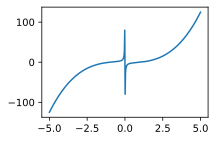

In [29]:
def f(x):
  return x**3 - 1 / x

y = f(x)

plt.figure(figsize=(3, 2))
plt.plot(x, y)

7. Find the gradient of the function
   $f(\mathbf{x}) = 3x_1^2 + 5e^{x_2}$.

In [32]:
import sympy as sp

x1, x2 = sp.symbols('x1 x2')

f = 3*x1**2 + 5*sp.exp(x2)

gradient = [
    sp.diff(f,x1),
    sp.diff(f,x2)
]

gradient

[6*x1, 5*exp(x2)]

8. What is the gradient of the function
   $f(\mathbf{x}) = \|\mathbf{x}\|_2$? What happens for $\mathbf{x} = \mathbf{0}$ (it's undefined given $0 / 0)?

In [35]:
import sympy as sp

x1, x2 = sp.symbols('x1 x2')

f = sp.sqrt(x1**2 + x2**2)

gradient = [
    sp.diff(f,x1),
    sp.diff(f,x2)
]

gradient

[0, 0]

9. Can you write out the chain rule for the case
   where $u = f(x, y, z)$ and $x = x(a, b)$, $y = y(a, b)$, and $z = z(a, b)$?

## Multivariable Chain Rule

We have:

$$
u = f(x,y,z)
$$

but $x,y,z$ depend on $a,b$:

$$
x=x(a,b)
$$

$$
y=y(a,b)
$$

$$
z=z(a,b)
$$

Therefore, $u$ is indirectly a function of $a,b$:

$$
u=f(x(a,b),y(a,b),z(a,b))
$$

The chain rule tells us how $u$ changes with respect to $a$ and $b$.

---

## Partial derivative with respect to $a$

$$
\frac{\partial u}{\partial a}
=
\frac{\partial u}{\partial x}\frac{\partial x}{\partial a}
+
\frac{\partial u}{\partial y}\frac{\partial y}{\partial a}
+
\frac{\partial u}{\partial z}\frac{\partial z}{\partial a}
$$

This represents the total change in $u$ through all paths:

- change through $x$
- change through $y$
- change through $z$

---

## Partial derivative with respect to $b$

$$
\frac{\partial u}{\partial b}
=
\frac{\partial u}{\partial x}\frac{\partial x}{\partial b}
+
\frac{\partial u}{\partial y}\frac{\partial y}{\partial b}
+
\frac{\partial u}{\partial z}\frac{\partial z}{\partial b}
$$

---

## Matrix Form

The chain rule can also be written as:

$$
\nabla_{a,b}u
=
J_{x,y,z}(a,b)^T \nabla_{x,y,z}f
$$

where the Jacobian matrix is:

$$
J =
\begin{bmatrix}
\frac{\partial x}{\partial a} & \frac{\partial x}{\partial b} \\
\frac{\partial y}{\partial a} & \frac{\partial y}{\partial b} \\
\frac{\partial z}{\partial a} & \frac{\partial z}{\partial b}
\end{bmatrix}
$$

and the gradient of $f$ is:

$$
\nabla f =
\begin{bmatrix}
\frac{\partial f}{\partial x} \\
\frac{\partial f}{\partial y} \\
\frac{\partial f}{\partial z}
\end{bmatrix}
$$

---

## Intuition

$$
\text{change in }u
=
(\text{how }u\text{ changes with }x,y,z)
\times
(\text{how }x,y,z\text{ change with }a,b)
$$

10. Given a function $f(x)$ that is invertible, compute the derivative of its inverse $f^{-1}(x)$.

    Here we have that $f^{-1}(f(x)) = x$ and conversely $f(f^{-1}(y)) = y$.
    
    Hint: use these properties in your derivation.

In [36]:
import sympy as sp

x = sp.symbols('x')
f = x**3 + 1
y = sp.symbols('y')
f_inverse = sp.solve(sp.Eq(y,f), x)[0]

print(f_inverse)

(y - 1)**(1/3)


## Derivative of an Inverse Function

We are given that:

$$
f^{-1}(f(x)) = x
$$

Use the chain rule on both sides.

Differentiate both sides with respect to $x$:

$$
\frac{d}{dx}f^{-1}(f(x))=\frac{d}{dx}x
$$

Using the chain rule:

$$
(f^{-1})'(f(x)) \cdot f'(x)=1
$$

Now solve for the derivative of the inverse function:

$$
(f^{-1})'(f(x))=\frac{1}{f'(x)}
$$

Therefore:

$$
\boxed{
(f^{-1})'(f(x))=\frac{1}{f'(x)}
}
$$

Since:

$$
y=f(x)
$$

we can rewrite the result in terms of $y$:

$$
\boxed{
(f^{-1})'(y)=\frac{1}{f'(f^{-1}(y))}
}
$$

This means the derivative of an inverse function is the reciprocal of the original function's derivative evaluated at the corresponding point.